# Recursividad en Python — Pila, Cola y Cruzada

**Curso:** Técnicas de Programación · Unidad 2
**Tema:** Recursividad

> Este notebook explica **qué es la recursividad**, la compara con la **iteración**, y desarrolla en profundidad sus **tres formas**:
> **recursión de pila**, **recursión de cola** y **recursión cruzada**. También cubre los **patrones de diseño** más comunes
> (Índice y Divide y Vencerás), los **límites de recursión** en Python, y ejemplos clásicos (memoización, recorridos de
> árboles), más **ejercicios guiados**. Búsqueda y backtracking se ven a fondo en la próxima sección de la unidad.
>
> 📎 **Material de apoyo (teoría y plantillas):** revisa primero la página [Recursividad](Recursividad.md) de esta unidad — tiene las
> diapositivas y el handout con más ejemplos y plantillas en blanco para practicar.


## Contenidos
1. [¿Qué es la recursividad?](#que-es)
2. [Recursividad vs Iteración](#rec-vs-it)
3. [Estructura de una función recursiva](#estructura)
4. [Los tres tipos de recursión: pila, cola y cruzada](#tres-tipos)
5. [Ejemplos básicos (patrón Índice)](#basicos)
    - Factorial (iterativo vs recursivo de pila)
    - Suma de lista (patrón Índice)
    - Fibonacci (naive, con memoización y versión iterativa)
6. [Recursión de cola en profundidad: transformar pila → cola](#cola-profundidad)
7. [Límites de recursión en Python](#limites)
8. [Recursión cruzada: `es_par` / `es_impar`](#cruzada)
9. [Divide y vencerás: potencia rápida (exponentiación binaria)](#byc)
10. [Recorridos de árboles binarios](#arboles)
11. [Programación dinámica (Top-Down vs Bottom-Up)](#dp)
12. [Bonus: visualiza el árbol de llamadas con un decorador](#trace)
13. [Ejercicios propuestos con plantillas](#ejercicios)
14. [Apéndice: consejos, errores frecuentes y material de apoyo](#apendice)


<a id="que-es"></a>
## 1) ¿Qué es la recursividad?
La **recursividad** es una técnica en la que una **función se llama a sí misma** para resolver un problema descomponiéndolo en
subproblemas más pequeños pero de la **misma forma**. En esencia, el diseño incluye siempre:
- **Caso base (condición de parada):** la forma más simple del problema que **no** hace llamadas recursivas.
- **Caso recursivo (reducción):** una llamada a la misma función (o a otra función, en la recursión cruzada) con el problema
  **más pequeño**, que **progresa** hacia el caso base.

> Piénsalo como muñecas rusas: vas abriendo versiones cada vez más pequeñas hasta llegar a la más simple.


<a id="rec-vs-it"></a>
## 2) Recursividad vs Iteración
- **Iteración**: usa bucles (`for`, `while`) y variables de control explícitas.
- **Recursividad**: delega el "bucle" al **call stack** del intérprete, expresando el algoritmo de forma muy cercana a su
definición matemática o estructural (p. ej., árboles).

**Regla práctica**: casi todo lo recursivo puede escribirse de forma iterativa; elegir uno u otro depende de **claridad**, **legibilidad**
y **eficiencia**.


<a id="estructura"></a>
## 3) Estructura de una función recursiva (plantilla)
1. **Validación de entrada** (opcional pero recomendable).
2. **Caso base**: retorna sin llamar de nuevo a la función.
3. **Caso recursivo**: llama a la función (o a otra, si es cruzada) con una versión más simple del problema y **combina** los resultados.

> Es **crítico** garantizar la **terminación**: cada llamada debe acercarse al caso base.


<a id="tres-tipos"></a>
## 4) Los tres tipos de recursión: pila, cola y cruzada

| Tipo | Idea central | ¿Qué queda pendiente al volver? |
|---|---|---|
| **De pila** | Cada llamada espera el resultado de la siguiente para poder terminar su propia operación | Una operación pendiente (multiplicar, sumar, concatenar...) — se van **apilando** marcos |
| **De cola** | La llamada recursiva es **lo último** que hace la función, y su resultado **es** el resultado final | Nada: el acumulador ya trae la respuesta lista |
| **Cruzada** | Dos (o más) funciones distintas se llaman **entre sí** (auto-invocación indirecta) hasta llegar a un caso base | Depende de cada función, pero el patrón es el mismo: caso base + progreso |

En las siguientes secciones vemos cada una con código y traza. Empezamos con recursión **de pila**, la más común y la que ya
conoces de la sección de Fuerza Bruta de esta unidad.


<a id="basicos"></a>
## 5) Ejemplos básicos (recursión de pila, patrón Índice)
Empezamos con **factorial**, el ejemplo clásico de recursión **de pila**: cada llamada debe esperar el resultado de `n-1` antes
de poder multiplicar y retornar.


In [1]:
def factorial_iterativo(n: int) -> int:
    """Calcula n! de forma iterativa."""
    if not isinstance(n, int):
        raise TypeError("n debe ser entero")
    if n < 0:
        raise ValueError("El factorial no está definido para n negativos")
    resultado = 1
    for i in range(1, n + 1):
        resultado *= i
    return resultado

def factorial_pila(n: int) -> int:
    """Calcula n! de forma recursiva de PILA: la multiplicación por n queda pendiente
    hasta que regresa la llamada de n-1."""
    if not isinstance(n, int):
        raise TypeError("n debe ser entero")
    if n < 0:
        raise ValueError("El factorial no está definido para n negativos")
    if n in (0, 1):   # Caso base
        return 1
    return n * factorial_pila(n - 1)  # <- multiplicar por n queda PENDIENTE hasta que vuelva la llamada

# Pruebas rápidas
for k in range(6):
    assert factorial_iterativo(k) == factorial_pila(k)
print("OK: factorial iterativo y recursivo (de pila) producen el mismo resultado para k=0..5")


OK: factorial iterativo y recursivo (de pila) producen el mismo resultado para k=0..5


### Patrón ÍNDICE: `suma_lista`
Este patrón recorre una estructura avanzando un índice (o "cortando" la lista con `xs[1:]`) hasta un caso base, y combina el
resultado al volver. Aquí mostramos la versión **de pila** (`suma_lista_pila`, con una suma pendiente) junto a una primera
aproximación **de cola** (`suma_lista_cola`, con un acumulador) — la profundizamos en la siguiente sección.


In [2]:
def suma_lista_pila(xs):
    """Patrón ÍNDICE, recursión DE PILA: la suma con xs[0] queda pendiente."""
    if not xs:                # Caso base: lista vacía
        return 0
    return xs[0] + suma_lista_pila(xs[1:])  # <- suma pendiente hasta que vuelve la llamada

def suma_lista_cola(xs, acumulador=0):
    """Patrón ÍNDICE, recursión DE COLA: el acumulador ya lleva la respuesta parcial,
    no queda ninguna operación pendiente al volver."""
    if not xs:                # Caso base
        return acumulador
    return suma_lista_cola(xs[1:], acumulador + xs[0])  # <- la llamada recursiva ES el resultado final

datos = [1, 2, 3, 4, 5]
print("suma_lista_pila:", suma_lista_pila(datos))
print("suma_lista_cola:", suma_lista_cola(datos))


suma_lista_pila: 15
suma_lista_cola: 15


In [3]:
from functools import lru_cache

def fib_naive(n: int) -> int:
    """Versión recursiva ingenua (de pila): O(phi^n) tiempo aprox, por recomputación."""
    if n < 2:
        return n
    return fib_naive(n-1) + fib_naive(n-2)

@lru_cache(maxsize=None)
def fib_memo(n: int) -> int:
    """Recursión con memoización (Top-Down). Tiempo O(n), espacio O(n)."""
    if n < 2:
        return n
    return fib_memo(n-1) + fib_memo(n-2)

def fib_iter(n: int) -> int:
    """Versión iterativa (Bottom-Up). Tiempo O(n), espacio O(1)."""
    if n < 2:
        return n
    a, b = 0, 1
    for _ in range(2, n+1):
        a, b = b, a + b
    return b

# Pruebas equivalentes
for n in range(20):
    assert fib_memo(n) == fib_iter(n)
print("OK: fib_memo y fib_iter coinciden para n=0..19")


OK: fib_memo y fib_iter coinciden para n=0..19


### Comparación de desempeño en Fibonacci
Medimos tiempo de ejecución de `fib_naive`, `fib_memo` y `fib_iter` para valores crecientes de `n`.
> **Nota:** No se especifican estilos ni colores para cumplir con la guía de gráficos.


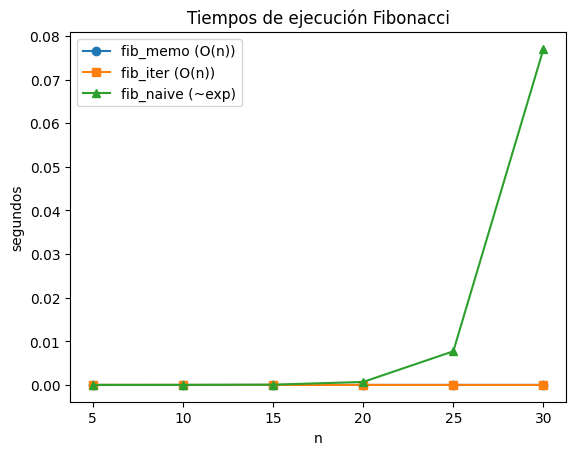

In [4]:
import time
import matplotlib.pyplot as plt

def medir_tiempo(fn, n):
    t0 = time.perf_counter()
    _ = fn(n)
    t1 = time.perf_counter()
    return t1 - t0

ns = list(range(5, 31, 5))
tiempos_naive = []
tiempos_memo  = []
tiempos_iter  = []

# Evitamos que el cache sesgue las primeras mediciones
fib_memo.cache_clear()

for n in ns:
    # Medimos varias veces para estabilizar
    repeticiones = 3
    t_naive = sum(medir_tiempo(fib_naive, n) for _ in range(repeticiones)) / repeticiones if n <= 35 else float('nan')
    t_memo  = sum(medir_tiempo(fib_memo,  n) for _ in range(repeticiones)) / repeticiones
    t_iter  = sum(medir_tiempo(fib_iter,  n) for _ in range(repeticiones)) / repeticiones
    tiempos_naive.append(t_naive)
    tiempos_memo.append(t_memo)
    tiempos_iter.append(t_iter)

plt.figure()
plt.plot(ns, tiempos_memo, marker='o', label='fib_memo (O(n))')
plt.plot(ns, tiempos_iter, marker='s', label='fib_iter (O(n))')
# Para naive, puede crecer rápido; mostramos si está disponible
import math
if not all(math.isnan(x) for x in tiempos_naive):
    plt.plot(ns, tiempos_naive, marker='^', label='fib_naive (~exp)')
plt.xlabel("n")
plt.ylabel("segundos")
plt.title("Tiempos de ejecución Fibonacci")
plt.legend()
plt.show()


<a id="cola-profundidad"></a>
## 6) Recursión de cola en profundidad: transformar pila → cola

```{image} _static/unidad2/recursividad/recursion_cola.png
:alt: Traza de recursion de cola de factorial_cola(4, acc=1), con el acumulador viajando ya resuelto
```

Una llamada es **de cola** cuando la llamada recursiva es **lo último** que hace la función — no hay ninguna operación
pendiente después de ella. Eso la hace, en teoría, optimizable (el intérprete podría reusar el marco de pila). **Python no
hace esa optimización** (no hay *tail-call optimization*), así que una recursión de cola sigue creando un marco por llamada
y puede agotar el límite de recursión igual que una de pila — la ventaja real es de **claridad**, no de memoria, salvo que
la conviertas en un bucle.

### Transformación en 5 pasos (de pila a cola)
1. **Identifica la operación pendiente** en la versión de pila (ej. `n * factorial_pila(n-1)`).
2. **Agrega un parámetro acumulador** con un valor inicial neutro para esa operación (`1` para producto, `0` para suma).
3. **Actualiza el acumulador antes de la llamada recursiva**, aplicando la operación pendiente sobre él (`acumulador * n`).
4. **Haz que la llamada recursiva sea el `return`**, sin nada más alrededor.
5. **El caso base retorna el acumulador** directamente — ya es la respuesta.

### De cola a iterativo (el paso final)
Como Python no optimiza la cola, el único beneficio real en memoria es convertir la recursión de cola en un **bucle `while`**:
el acumulador de la versión de cola se vuelve, casi literalmente, la variable que actualiza el bucle.


In [5]:
def factorial_pila(n):
    if n in (0, 1):
        return 1
    return n * factorial_pila(n - 1)          # operación pendiente: multiplicar por n

def factorial_cola(n, acumulador=1):
    if n in (0, 1):
        return acumulador                      # el acumulador YA es la respuesta
    return factorial_cola(n - 1, acumulador * n)  # último paso: nada pendiente después

def factorial_iterativo_desde_cola(n):
    """El acumulador de factorial_cola se vuelve la variable del bucle."""
    acumulador = 1
    while n > 1:
        acumulador *= n
        n -= 1
    return acumulador

for k in range(8):
    assert factorial_pila(k) == factorial_cola(k) == factorial_iterativo_desde_cola(k)
print("OK: las tres versiones (pila, cola, iterativa) coinciden para k=0..7")

# Prueba de que Python NO optimiza la cola: ambas formas agotan la pila con el mismo N aprox.
import sys
limite = sys.getrecursionlimit()
n_grande = limite + 50
try:
    factorial_cola(n_grande)
    print("No debería llegar aquí")
except RecursionError:
    print(f"RecursionError con n={n_grande}: la version de cola tambien crea un marco por llamada")


OK: las tres versiones (pila, cola, iterativa) coinciden para k=0..7
RecursionError con n=1050: la version de cola tambien crea un marco por llamada


<a id="limites"></a>
## 7) Límites de recursión en Python
Python protege contra desbordamientos de pila con un **límite de recursión**. Puedes consultarlo, y con cuidado, ajustarlo.


In [6]:
import sys

print("Límite actual:", sys.getrecursionlimit())

def rec_sin_fin(n):
    return rec_sin_fin(n + 1)

try:
    rec_sin_fin(0)
except RecursionError as e:
    print("Atrapado un RecursionError real:", e)

# ¡Usar con precaución! Subir el límite no arregla una recursión mal diseñada,
# solo pospone el problema y puede colgar el intérprete en casos extremos.
# sys.setrecursionlimit(3000)


Límite actual: 1000
Atrapado un RecursionError real: maximum recursion depth exceeded


<a id="cruzada"></a>
## 8) Recursión cruzada (auto-invocación indirecta)

```{image} _static/unidad2/recursividad/recursion_cruzada.png
:alt: es_par(4) y es_impar se llaman mutuamente hasta llegar al caso base es_par(0) = True
```

En la recursión **cruzada** (o **mutua**), una función `A` llama a una función `B`, y `B` vuelve a llamar a `A` — ninguna se
llama directamente a sí misma, pero la cadena de llamadas sigue creciendo (y reduciéndose) igual que en una recursión normal.
Es el mismo contrato de siempre: **cada función necesita su propio caso base**, y cada llamada debe **progresar** hacia él.

Aparece de forma natural en **parsers** (una función que reconoce expresiones llama a otra que reconoce términos, que llama
de vuelta a la de expresiones) y en **máquinas de estados** implementadas con funciones.


In [7]:
def es_par(n):
    """Caso base: 0 es par. Si no, pregunta si n-1 es impar (llamando a OTRA función)."""
    if n == 0:
        return True
    return es_impar(n - 1)

def es_impar(n):
    """Caso base: 0 no es impar. Si no, pregunta si n-1 es par (llamando a OTRA función)."""
    if n == 0:
        return False
    return es_par(n - 1)

for n in range(10):
    assert es_par(n) == (n % 2 == 0)
    assert es_impar(n) == (n % 2 == 1)
print("OK: es_par/es_impar (recursion cruzada) coinciden con el operador % para n=0..9")
print("es_par(4) ->", es_par(4), " | es_impar(7) ->", es_impar(7))


OK: es_par/es_impar (recursion cruzada) coinciden con el operador % para n=0..9
es_par(4) -> True  | es_impar(7) -> True


<a id="byc"></a>
## 9) Divide y vencerás: potencia rápida (exponentiación binaria)

### Patrón DIVIDE Y VENCERÁS
Este patrón parte el problema en subproblemas independientes, resuelve el subproblema y combina el resultado. Para calcular
`a**n` no hace falta multiplicar `a` por sí mismo `n` veces: si `n` es par, `a**n = (a**(n//2))**2`, y si es impar,
`a**n = a * a**(n-1)`. Cada llamada **parte el exponente a la mitad**, así que en vez de `n` llamadas necesitamos solo
`O(log n)`.

> **Nota:** la búsqueda binaria y el backtracking (Torres de Hanoi, generación de subconjuntos, N-Reinas) también son
> ejemplos naturales de estos patrones — los vas a ver a fondo en la próxima sección de la unidad, dedicada a
> **búsqueda y backtracking**.


In [8]:
def potencia_dyc(a, n):
    """Calcula a**n con exponenciacion rapida (divide y venceras). n entero >= 0."""
    if n == 0:              # Caso base
        return 1
    mitad = potencia_dyc(a, n // 2)      # subproblema: parte el exponente a la mitad
    if n % 2 == 0:
        return mitad * mitad             # combinar: n par
    else:
        return a * mitad * mitad         # combinar: n impar

for base in (2, 3, 5):
    for exp in range(6):
        assert potencia_dyc(base, exp) == base ** exp
print("OK: potencia_dyc coincide con ** para bases 2,3,5 y exponentes 0..5")
print("potencia_dyc(2, 10) ->", potencia_dyc(2, 10))


OK: potencia_dyc coincide con ** para bases 2,3,5 y exponentes 0..5
potencia_dyc(2, 10) -> 1024


<a id="arboles"></a>
## 10) Recorridos de árboles binarios (pre/in/post-orden)
Las estructuras jerárquicas se describen naturalmente con recursividad **de pila**: cada llamada combina lo que retornan sus
dos hijos.


In [9]:
class Nodo:
    def __init__(self, valor, izq=None, der=None):
        self.valor = valor
        self.izq = izq
        self.der = der

def preorden(nodo):
    if nodo is None: return []
    return [nodo.valor] + preorden(nodo.izq) + preorden(nodo.der)

def inorden(nodo):
    if nodo is None: return []
    return inorden(nodo.izq) + [nodo.valor] + inorden(nodo.der)

def postorden(nodo):
    if nodo is None: return []
    return postorden(nodo.izq) + postorden(nodo.der) + [nodo.valor]

# Árbol de ejemplo
#         4
#       /   \
#      2     6
#     / \   / \
#    1   3 5   7
tree = Nodo(4,
            Nodo(2, Nodo(1), Nodo(3)),
            Nodo(6, Nodo(5), Nodo(7)))

print("Preorden:  ", preorden(tree))
print("Inorden:   ", inorden(tree))
print("Postorden: ", postorden(tree))


Preorden:   [4, 2, 1, 3, 6, 5, 7]
Inorden:    [1, 2, 3, 4, 5, 6, 7]
Postorden:  [1, 3, 2, 5, 7, 6, 4]


<a id="dp"></a>
## 11) Programación dinámica: Top-Down (memoización) vs Bottom-Up
La recursión combinada con **memoización** evita recomputaciones; la alternativa iterativa **Bottom-Up** construye la solución
desde los casos base. Ya lo vimos con Fibonacci; otro ejemplo ilustrativo es el **cambio de monedas**.


In [10]:
from functools import lru_cache

def cambio_minimo_bottom_up(valor, monedas):
    """Número mínimo de monedas para alcanzar 'valor'. Bottom-Up (iterativo)."""
    INF = 10**9
    dp = [0] + [INF]*valor
    for v in range(1, valor+1):
        for m in monedas:
            if m <= v:
                dp[v] = min(dp[v], 1 + dp[v-m])
    return dp[valor] if dp[valor] < INF else None

@lru_cache(maxsize=None)
def cambio_minimo_top_down(valor, monedas_tuple):
    """Top-Down (recursivo con memo). monedas_tuple para permitir cache."""
    if valor == 0:
        return 0
    INF = 10**9
    ans = INF
    for m in monedas_tuple:
        if m <= valor:
            sub = cambio_minimo_top_down(valor - m, monedas_tuple)
            if sub is not None:
                ans = min(ans, 1 + sub)
    return ans if ans < INF else None

monedas = (1, 3, 4)
v = 6
print("Bottom-Up:", cambio_minimo_bottom_up(v, list(monedas)))
cambio_minimo_top_down.cache_clear()
print("Top-Down :", cambio_minimo_top_down(v, monedas))


Bottom-Up: 2
Top-Down : 2


<a id="trace"></a>
## 12) Bonus: visualiza el árbol de llamadas con un decorador
Este pequeño decorador imprime cada llamada con sangría según su profundidad, y su retorno al volver — útil para **ver** el
árbol de llamadas de cualquier función recursiva sin dibujarlo a mano.


In [11]:
from functools import wraps

def trace(fn):
    def indent(depth):
        return '│ ' * (depth - 1) + ('├─ ' if depth > 0 else '')

    @wraps(fn)
    def wrapper(*args, **kwargs):
        depth = wrapper.depth
        print(f"{indent(depth)}{fn.__name__}{args}")
        wrapper.depth += 1
        res = fn(*args, **kwargs)
        wrapper.depth -= 1
        print(f"{indent(depth)}-> {res}")
        return res

    wrapper.depth = 0
    return wrapper

@trace
def suma_trazada(a, i=0):
    if i == len(a):
        return 0
    return a[i] + suma_trazada(a, i + 1)

suma_trazada([2, 4, 1])


suma_trazada([2, 4, 1],)
├─ suma_trazada([2, 4, 1], 1)
│ ├─ suma_trazada([2, 4, 1], 2)
│ │ ├─ suma_trazada([2, 4, 1], 3)
│ │ ├─ -> 0
│ ├─ -> 1
├─ -> 5
-> 7


7

<a id="ejercicios"></a>
## 13) Ejercicios propuestos (con plantillas)

### A) Invertir una lista recursivamente
- Implementa una función que retorne una **nueva lista invertida** usando recursión.

```python
def invertir(xs):
    # TODO
    ...
```

### B) Profundidad máxima de un árbol binario
- Dado un `Nodo` (como en la sección de árboles), calcula la **altura** del árbol.

```python
def altura(nodo):
    # TODO
    ...
```

### C) Convierte `suma_lista_pila` a una versión de cola con acumulador
- Sigue la **transformación en 5 pasos** de la sección 6 y verifica que ambas versiones coinciden.

### D) Recursión cruzada: `es_multiplo_de_3` / `resto_de_3`
- Escribe dos funciones que se llamen mutuamente para calcular `n % 3` sin usar el operador `%` (usa restas de a uno).

### E) Divide y vencerás: `potencia_dyc` con exponente negativo
- Extiende `potencia_dyc(a, n)` para que acepte `n` negativo, devolviendo `1 / a**abs(n)`.


<a id="apendice"></a>
## 14) Apéndice: consejos, errores frecuentes y material de apoyo

**Consejos**
- **Define primero el caso base**, luego el caso recursivo (o los casos recursivos, si es cruzada).
- **Verifica progresión** hacia el caso base (evita recursión infinita).
- **Entrada válida**: valida tipos y rangos cuando sea pertinente.
- **Cuidado con Python y recursión de cola**: Python **no** hace *tail-call optimization* — una recursión de cola sigue
  gastando un marco de pila por llamada.
- **Límites de recursión**: consulta/ajusta con `sys.getrecursionlimit()` y `sys.setrecursionlimit()` con prudencia.
- **Perfílalo**: si una recursión es lenta por recomputación, usa **memoización** o considera una versión iterativa.

**Errores frecuentes**
- Olvidar el caso base, o tenerlo inalcanzable.
- No avanzar hacia el caso base (un parámetro que no cambia).
- Modificar listas en sitio sin control (usa copias, o deshaz un `append` con `pop()` si acumulas sobre una sola lista compartida).
- Mezclar retornos y efectos secundarios (decide si la función *devuelve* o *imprime/guarda*).
- No probar con casos vacío y de tamaño 1.

**Material de apoyo (teoría completa y plantillas en blanco)**
- [Recursividad en Python — introducción (PDF)](_static/unidad2/recursividad/RecursividadenPython.pdf)
- [Patrones esenciales: Índice, Divide y Vencerás, Incluir/Excluir (PDF)](_static/unidad2/recursividad/RecursividadPatronesEsenciales.pdf)
- [Recursión de cola: teoría, patrones y práctica (PDF)](_static/unidad2/recursividad/RecursionDeCola.pdf)
- [Plantillas de aula para practicar los tres patrones (PDF)](_static/unidad2/recursividad/PlantillasRecursividad_handout.pdf)
- [Diagramas de árbol y trazas recursivas (PDF)](_static/unidad2/recursividad/DiagramasArbolTrazaRecursiva.pdf)

> Con práctica, podrás identificar problemas **naturalmente recursivos** (árboles, divide y vencerás) y elegir con criterio
> entre recursión de pila, de cola o cruzada — y saber cuándo conviene pasarlos a una versión iterativa. La próxima sección
> de la unidad retoma estos mismos patrones para **búsqueda y backtracking**.
